<a href="https://colab.research.google.com/github/ByteNinjaMaster/AI_ML_Final_Assignment/blob/main/2408948_Jenish_Prakash_Singh_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name - Jenish Prakash Singh
ID - 2408948

In [55]:
# imports and Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from wordcloud import WordCloud
import gradio as gr

In [56]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# file path
file_path = '/content/drive/My Drive/2. Hotel Review Dataset/Hotel_Reviews.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# Downloading Dependency NLP tools
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [58]:
# Task 4.5.1 - Text Preprocessing
# Loading the CSV
df = pd.read_csv(file_path)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

# Apply cleaning
df['cleaned_review'] = df['Review'].apply(clean_text)
print("Data Cleaning Complete.")

Data Cleaning Complete.


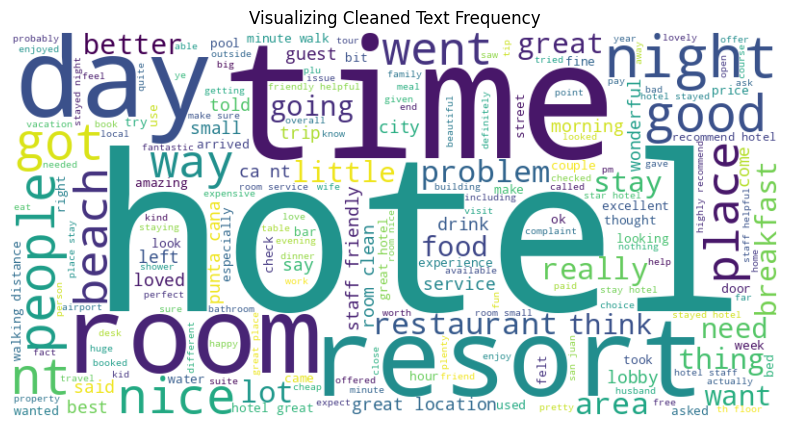

In [59]:
# Data Visualization (Word Cloud)
from wordcloud import WordCloud

# Visualize most frequent words
all_text = " ".join(review for review in df.cleaned_review)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Visualizing Cleaned Text Frequency")
plt.show()


In [60]:
# Tokenization and Sequence Padding
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# Padding to ensure all reviews are the same length (95th percentile)
maxlen = int(np.percentile([len(x) for x in sequences], 95))
X = pad_sequences(sequences, maxlen=maxlen)

# Target variables (1-5 rating converted to categorical format)
y = pd.get_dummies(df['Rating']).values

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Calculating class weights to handle imbalance (more 5-star reviews than 1-star)
y_integers = np.argmax(y_train, axis=1)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights_dict = dict(enumerate(weights))

In [61]:
# Task 4.5.2 - Model Building
def build_dl_model(type="RNN", use_pretrained=False):
    model = Sequential()

    if use_pretrained:
        # Pretrained Embedding Placeholder (Model 3)
        embedding_matrix = np.random.random((max_words, 50))
        model.add(Embedding(max_words, 50, weights=[embedding_matrix], trainable=False))
    else:
        # Standard Trainable Embedding (Model 1 & 2)
        model.add(Embedding(max_words, 50))

    if type == "RNN":
        model.add(SimpleRNN(64, dropout=0.2))
    else:
        model.add(LSTM(64, dropout=0.2))

    model.add(Dense(5, activation='softmax')) # 5 rating classes
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train Model 1: Simple RNN
print("Training Model 1: Simple RNN...")
model1 = build_dl_model("RNN")
history1 = model1.fit(X_train, y_train, epochs=5, validation_split=0.1, class_weight=class_weights_dict)

# Train Model 2: LSTM
print("Training Model 2: LSTM...")
model2 = build_dl_model("LSTM")
history2 = model2.fit(X_train, y_train, epochs=5, validation_split=0.1, class_weight=class_weights_dict)

# Train Model 3: LSTM with Pretrained Embeddings
print("Training Model 3: LSTM Pretrained...")
model3 = build_dl_model("LSTM", use_pretrained=True)
history3 = model3.fit(X_train, y_train, epochs=5, validation_split=0.1, class_weight=class_weights_dict)

Training Model 1: Simple RNN...
Epoch 1/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - accuracy: 0.3312 - loss: 1.4797 - val_accuracy: 0.4787 - val_loss: 1.2145
Epoch 2/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.5455 - loss: 1.0825 - val_accuracy: 0.4768 - val_loss: 1.1258
Epoch 3/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 36s 78ms/step - accuracy: 0.6681 - loss: 0.6905 - val_accuracy: 0.4195 - val_loss: 1.2907
Epoch 4/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.7709 - loss: 0.4056 - val_accuracy: 0.4427 - val_loss: 1.4655
Epoch 5/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 36s 78ms/step - accuracy: 0.8505 - loss: 0.2550 - val_accuracy: 0.4787 - val_loss: 1.5256
Training Model 2: LSTM...
Epoch 1/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 68s 142ms/step - accuracy: 0.4710 - loss: 1.3001 - val_accuracy: 0.4768 - val_loss: 1.1560
Epoch 2/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 67s 146ms/step - accuracy: 0.5731 - loss: 0.9903 - val_accuracy: 0.5073 - val_loss: 1.0439
Epoch 3/5
461/461 ━━━━━━━━━━━━━━━━━━━

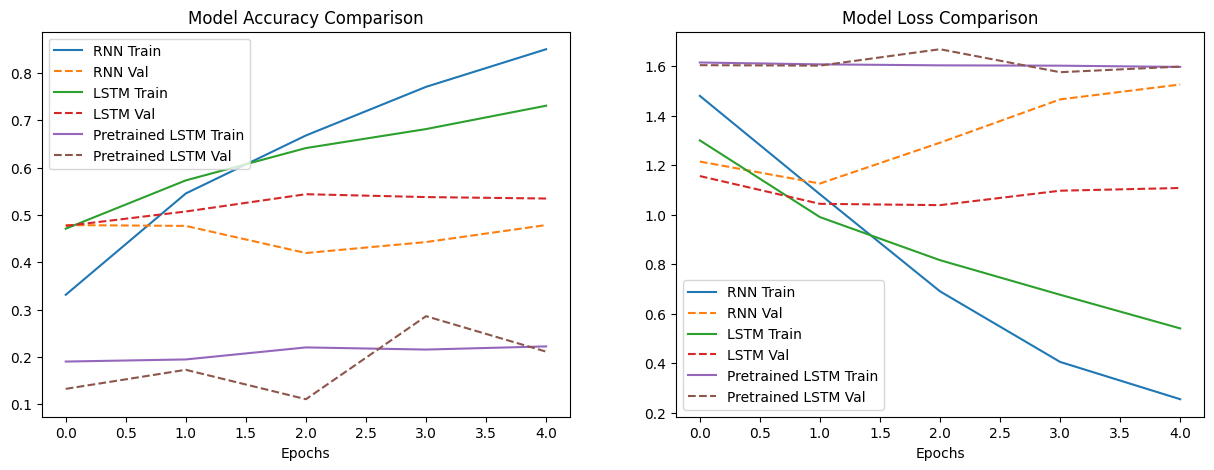

In [62]:
# Task 4.5.3 - Training Visualizations
def plot_history_comparison(histories, names):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for i, hist in enumerate(histories):
        # Accuracy curves
        ax1.plot(hist.history['accuracy'], label=f'{names[i]} Train')
        ax1.plot(hist.history['val_accuracy'], linestyle='--', label=f'{names[i]} Val')
        # Loss curves
        ax2.plot(hist.history['loss'], label=f'{names[i]} Train')
        ax2.plot(hist.history['val_loss'], linestyle='--', label=f'{names[i]} Val')

    ax1.set_title('Model Accuracy Comparison')
    ax1.set_xlabel('Epochs')
    ax1.legend()

    ax2.set_title('Model Loss Comparison')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    plt.show()

plot_history_comparison([history1, history2, history3], ['RNN', 'LSTM', 'Pretrained LSTM'])

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step
--- Classification Report ---


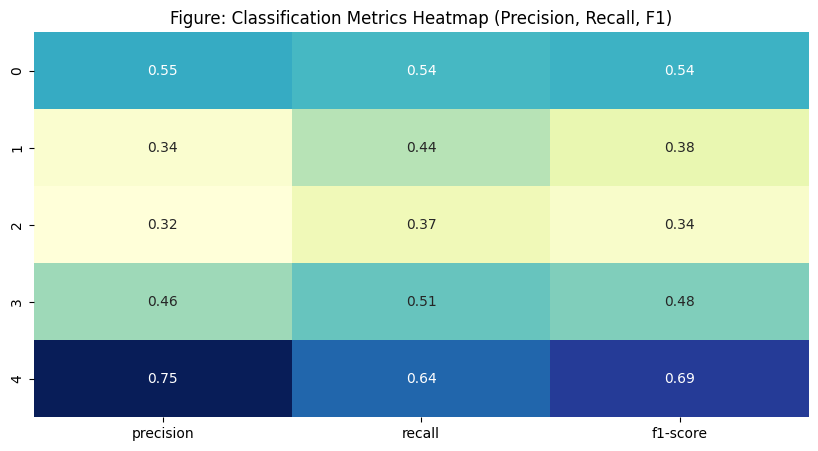

--- Confusion Matrix ---


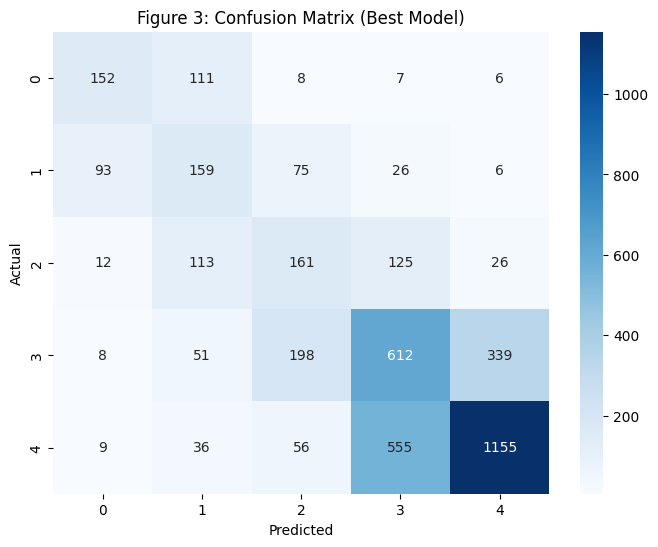

In [63]:
# Model Evaluation Metrics
# Evaluate the best performing model (usually LSTM)
predictions = np.argmax(model2.predict(X_test), axis=1)
actuals = np.argmax(y_test, axis=1)

print("--- Classification Report ---")
report = classification_report(actuals, predictions, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :5].T # Filter for classes 1-5

plt.figure(figsize=(10, 5))
sns.heatmap(report_df, annot=True, cmap="YlGnBu", cbar=False)
plt.title("Figure: Classification Metrics Heatmap (Precision, Recall, F1)")
plt.show()

print("--- Confusion Matrix ---")
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(actuals, predictions), annot=True, fmt='d', cmap='Blues')
plt.title("Figure 3: Confusion Matrix (Best Model)")
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step

--- Visualizing Misclassified Examples ---


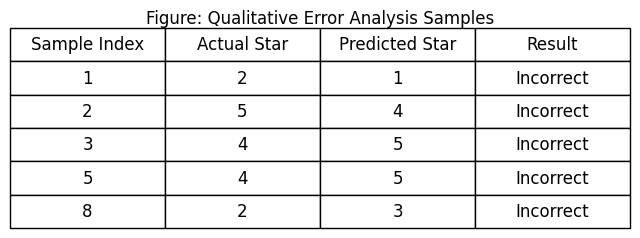

Index 1 | Actual: 2 | Predicted: 1
Index 2 | Actual: 5 | Predicted: 4
Index 3 | Actual: 4 | Predicted: 5


In [64]:
# Task 4.5.4: Error Analysis
y_pred_classes = np.argmax(model2.predict(X_test), axis=1) + 1
y_true_classes = np.argmax(y_test, axis=1) + 1
errors = np.where(y_pred_classes != y_true_classes)[0]

# New code: Visual Error Analysis Table
print("\n--- Visualizing Misclassified Examples ---")
error_data = []
for i in errors[:5]: # Take top 5 errors
    error_data.append({
        "Sample Index": i,
        "Actual Star": y_true_classes[i],
        "Predicted Star": y_pred_classes[i],
        "Result": "Incorrect"
    })

error_df = pd.DataFrame(error_data)

# Identify misclassified samples
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
table = ax.table(cellText=error_df.values, colLabels=error_df.columns, loc='center', cellLoc='center')
table.set_fontsize(12)
table.scale(1, 2)
plt.title("Figure: Qualitative Error Analysis Samples", pad=20)
plt.show()


for i in errors[:3]:
    print(f"Index {i} | Actual: {y_true_classes[i]} | Predicted: {y_pred_classes[i]}")

In [65]:
# Task 4.5.5 - Real-Time Prediction GUI
!pip install gradio -q
import gradio as gr

def predict_review(user_input):
    # 1. Preprocess input
    cleaned = clean_text(user_input)
    # 2. Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=maxlen)
    # 3. Predict using the best model (Model 2)
    pred = model2.predict(padded)
    rating = np.argmax(pred) + 1
    return f"Predicted Rating: {rating} Stars"

# Create Gradio Interface
demo = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=3, placeholder="Enter hotel review here..."),
    outputs="text",
    title="Hotel Review Rating Predictor"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d20f732dbdb7ea432.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
